# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

This is a supervised machine learning regression problem, that aims at identifying the key determinants of a continuous target variable(used car price) based on various feature attributes( mileage, year, manufacturer). I employed Exploratory Data Analysis(EDA) and feature engineering on the dataset to identify influential predictores.

Steps to Explore the data:
1- import the data
2-To identify each column, possible values, min,max and others
3-To identify missing values
4- Remove or adjust data set arounf missed values
5- Transform categorical columns using Target encoder
6- To identify relations of each column by executing correlations
7- To explore the importance of each column with the price
8- To developed a predictive model to quantify the impact of these factors on pricing.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
!pip install ydata-profiling
!pip install category-encoders
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn import set_config
set_config(display='diagram')
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.inspection import permutation_importance
from ydata_profiling import ProfileReport
from category_encoders import TargetEncoder
from sklearn.feature_selection import SequentialFeatureSelector

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [2]:
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import io

# Get the first (and usually only) filename from the uploaded dictionary
# This makes the code robust to Colab's dynamic renaming of uploaded files.
if uploaded:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(df.head())
else:
    print("No file was uploaded.")


Saving vehicles.csv to vehicles.csv
           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az 

In [4]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

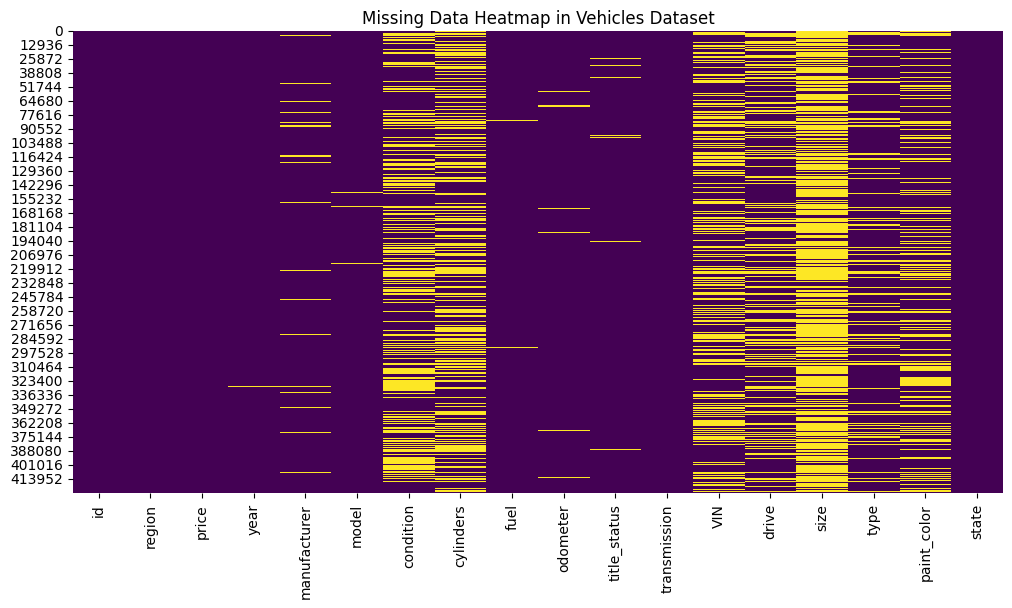

In [7]:
# missed data plot
df= pd.read_csv(io.BytesIO(uploaded['vehicles.csv']))
plt.figure(figsize=(12, 6))
ax= sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap in Vehicles Dataset')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [8]:
import re

df_clean= df.query('price>0')
df_clean= df_clean.drop(['id','VIN', 'region','size', 'paint_color','drive'], axis=1)

#Filling
df_clean["year"] = df_clean["year"].fillna(df_clean["year"].mode()[0])
df_clean['year'] = df_clean['year'].apply(lambda x: int(x))
df_clean["manufacturer"] = df_clean["manufacturer"].fillna('other')
df_clean["model"] = df_clean["model"].fillna('other')
df_clean["condition"]= df_clean["condition"].fillna(df_clean["condition"].mode()[0])
df_clean["cylinders"]= df_clean['cylinders'].str.replace(' cylinders', '')
df_clean["cylinders"]= df_clean["cylinders"].fillna(df_clean["cylinders"].mode()[0])
df_clean["cylinders"] = df_clean['cylinders'].str.replace('other', df_clean["cylinders"].mode()[0])
df_clean["cylinders"] = pd.to_numeric(df_clean['cylinders'])
df_clean["fuel"]= df_clean["fuel"].fillna('other')
df_clean["odometer"]= df_clean["odometer"].fillna(df_clean["odometer"].mean())
df_clean["title_status"]= df_clean["title_status"].fillna(df_clean["title_status"].mode()[0])
df_clean["transmission"]= df_clean["transmission"].fillna('other')
df_clean["type"]= df_clean["type"].fillna('other')

#Function used to extract the first word of the model
def first_words(item):
    model= item["model"]
    segments= re.split(r"[,!?:]+", model)
    index= 0
    value= segments[index]

    #if the model is compound with the manufacturer name
    if(value==item["manufacturer"]):
        index+=1
        if(len(segments)>index):
            value= segments[index]


    return value.title()

df_clean['model']= df_clean['model'].str.replace('-','')
df_clean['model']= df_clean.apply(first_words, axis=1)

#Removing innacurate records: First vehicle with automatic transmission started at 1948
df_clean= df_clean.query('year>=1948')

#Removing duplicated records
df= df_clean.drop_duplicates()
df.sample(10)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,state
162441,25999,2016,acura,Mdx,excellent,6,gas,63892.0,clean,automatic,SUV,ia
195536,54988,2020,ford,F150,good,6,gas,15330.0,clean,automatic,truck,mi
388623,29995,2015,chevrolet,Silverado 1500,excellent,8,gas,65462.0,clean,automatic,other,vt
113775,6599,2014,chevrolet,Cruze,excellent,4,gas,79000.0,clean,manual,sedan,fl
184015,20590,2019,mitsubishi,Outlander Es Sport,good,6,gas,19576.0,clean,other,other,md
373902,1550,2001,nissan,Xterra,fair,6,gas,176854.0,clean,automatic,SUV,tx
251157,3500,2007,other,Saab 93 Convertible,good,4,gas,68000.0,rebuilt,automatic,convertible,nj
73574,10590,2013,nissan,Altima,good,4,gas,103976.0,clean,automatic,sedan,co
380918,2350,1994,ford,Econoline,good,6,gas,110000.0,clean,automatic,other,tx
221147,29990,2017,ford,Mustang Gt Coupe 2D,good,8,gas,14113.0,clean,other,coupe,mo


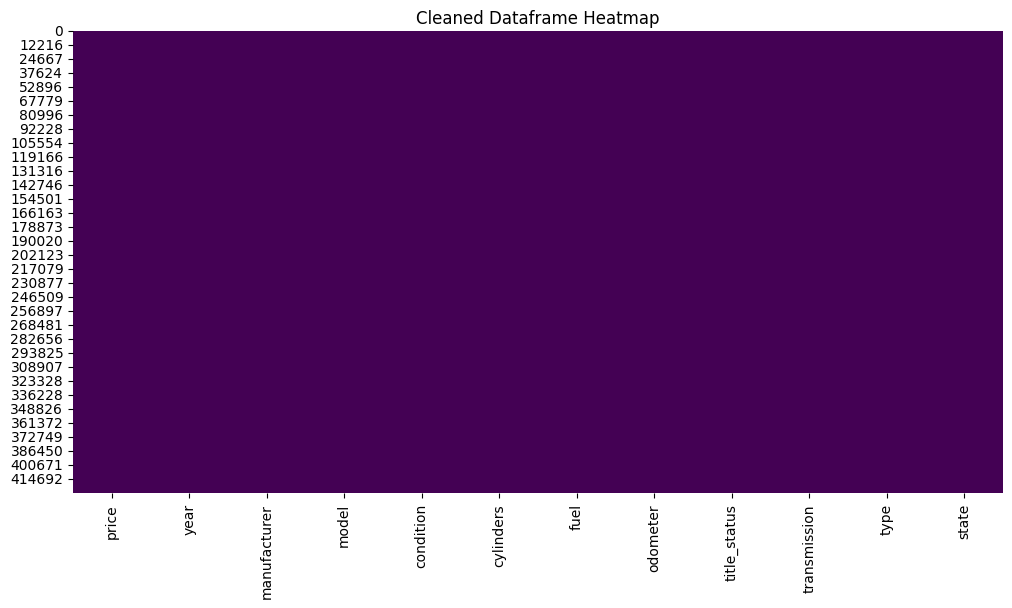

In [9]:
#Re-evaluating missed values using heatmap
plt.figure(figsize=(12, 6))
ax= sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Cleaned Dataframe Heatmap')
plt.show()


In [10]:
#Detect Outliers and return the DF filtered
def outliers_filter(df,column):
    factor = 1.5
    first_quartile= df[column].quantile (.25)
    third_quartile= df[column].quantile (.75)
    iqr= third_quartile - first_quartile
    lower= first_quartile - (factor*iqr)
    upper= third_quartile + (factor*iqr)
    print(f'lower:{lower}, upper:{upper}')
    return
outliers_filter(df,'price')

#Redefine outliers using approximated values based  on suggested results
lower= 100
upper= 7000
df_without_outliers= df.query('price>=@lower and price<=@upper')
df_without_outliers

lower:-21682.75, upper:53471.25


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,state
0,6000,2018,other,Other,good,6,other,98729.511212,clean,other,other,az
3,1500,2018,other,Other,good,6,other,98729.511212,clean,other,other,ma
4,4900,2018,other,Other,good,6,other,98729.511212,clean,other,other,nc
5,1600,2018,other,Other,good,6,other,98729.511212,clean,other,other,ny
6,1000,2018,other,Other,good,6,other,98729.511212,clean,other,other,ny
...,...,...,...,...,...,...,...,...,...,...,...,...
426833,6800,1997,jaguar,Xk8 Convertible,good,8,gas,69550.000000,clean,automatic,convertible,wy
426848,4277,2005,honda,Civic,good,6,gas,236787.000000,clean,automatic,coupe,wy
426851,6577,2013,hyundai,Elantra,good,6,gas,169396.000000,clean,manual,sedan,wy
426852,6977,2011,honda,Civic,good,6,gas,112396.000000,clean,automatic,sedan,wy


[Text(0.5, 1.0, 'Price Distribution without outliers')]

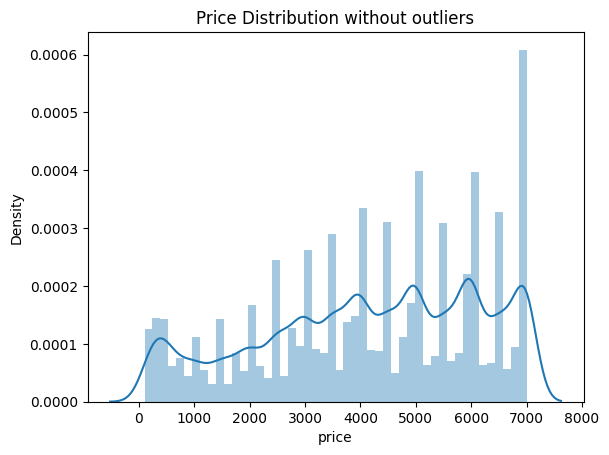

In [11]:
#Visualization to review price distribution without outliers
sns.distplot(df_without_outliers['price']).set(title= "Price Distribution without outliers")

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [12]:
#Build train and test set
# Splitting the dataset into Train and Test
X= df_without_outliers.drop('price',axis=1)
y= df_without_outliers['price']
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=42)

# Columns used into regressions excluding my objective(price)
features= X.columns

#Get categorical columns
cat_columns= df_without_outliers.select_dtypes(include='object').columns
cat_columns




Index(['manufacturer', 'model', 'condition', 'fuel', 'title_status',
       'transmission', 'type', 'state'],
      dtype='object')

In [13]:
#Simple Linear Regression
# Encoding columns to apply regression
target_encoder= TargetEncoder()
df_target_encoded=target_encoder.fit_transform(df_without_outliers[features], df_without_outliers ["price"])

X1= df_target_encoded
y1= df_without_outliers["price"]
X1_train, X1_test, y1_train, y1_test= train_test_split(X1,y1, test_size=0.3, random_state=42)

#Training the model with LinearRegression
first_degree_model= LinearRegression().fit(X1_train,y1_train)

#Executing Predictions
pred_train= first_degree_model.predict(X1_train[features])
pred_test= first_degree_model.predict(X1_test[features])

#Obtaining errors for training and test datasets
train_mse= mean_squared_error(y_train, pred_train)
test_mse= mean_squared_error(y_test, pred_test)

train_r2= r2_score(y_train, pred_train)
test_r2= r2_score(y_test, pred_test)

#Collection results
reg_results={'model':'simpleRegression','train_mse': train_mse, 'test_mse':test_mse,'train_r2':train_r2, 'test_r2':test_r2}
# Make sure `results` list is defined, if not, initialize it.
if 'results' not in locals():
    results = []
results.append(reg_results)


In [14]:
#Perform a Linear Regression with Polynomial Features
#Using GridSearchCV, including Target encoder and polynomial features
column_transformer= make_column_transformer(
    (TargetEncoder(), cat_columns),
    (PolynomialFeatures(), make_column_selector(dtype_include=np.number))
)

#Defining a pipeline doing columns transformations, scaling data and performing LinearRegression
pipe= Pipeline([('transformer', column_transformer), ('scaler', StandardScaler()), ('linreg', LinearRegression())])

#Different degrees to use over the PolynomialFeatures function
param_dict={'transformer__polynomialfeatures__degree': [1,2,3,4,5]}
gscv_linreg= GridSearchCV(pipe, param_grid=param_dict)

#Training the model
gscv_linreg.fit(X_train[features], y_train)

GridSearchCV(estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('targetencoder',
                                                                         TargetEncoder(),
                                                                         Index(['manufacturer', 'model', 'condition', 'fuel', 'title_status',
       'transmission', 'type', 'state'],
      dtype='object')),
                                                                        ('polynomialfeatures',
                                                                         PolynomialFeatures(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7a7b0298f7a0>)])),
                                       ('scaler', StandardScaler()),
                                       ('linreg', LinearRegression())]),
             param_grid={'transformer__polynomialfeatures__degree': [1, 2, 3, 4,
                                                                     5]})

In [15]:
#Obtaining predictions
pre_train= gscv_linreg.best_estimator_.predict(X_train[features])
pre_test= gscv_linreg.best_estimator_.predict(X_test[features])

#Evaluating the errors
train_mse= mean_squared_error(y_train,pred_train)
test_mse= mean_squared_error(y_test,pred_test)

train_r2= r2_score(y_train,pred_train)
test_r2= r2_score(y_test,pred_test)

#Reporting results for this regression model
reg_results={'model':'linearRegressionWithPF','train_mse': train_mse, 'test_mse':test_mse,'train_r2':train_r2,'test_r2':test_r2}
results.append(reg_results)



In [18]:
#Ridge Regression with Polynomial features
# Making transformations (TargetEncoder) and including polynomial features
column_transformer= make_column_transformer(
    (PolynomialFeatures(),make_column_selector(dtype_include=np.number)),
    (TargetEncoder(), cat_columns),)

#Pipeline to transform, scale and to execute a ridge regression
pipe= Pipeline([('transformer', column_transformer), ('scaler', StandardScaler()), ('ridge', Ridge())])

#Possible values to evaluate over the polynomial features
param_dict={'transformer__polynomialfeatures__degree': [1,2,3,4,5], 'ridge__alpha': np.logspace(0,5,10)}
gsvc_ridge= GridSearchCV(pipe, param_grid=param_dict)

#Training the model
gsvc_ridge.fit(X_train[features], y_train)

GridSearchCV(estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('polynomialfeatures',
                                                                         PolynomialFeatures(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7a7b050f20c0>),
                                                                        ('targetencoder',
                                                                         TargetEncoder(),
                                                                         Index(['manufacturer', 'model', 'condition', 'fuel', 'title_status',
       'transmission', 'type', 'state'],
      dtype='object'))])),
                                       ('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': array([1.00000000e+00, 3.59381366e+00, 1.29154967e+01, 4.64158883e+01,
       1.66810054e+02, 5.99484250e+02, 2.15443469e+03, 7.74263683e+03,
       2.78255940e+04, 1.00000000e+05]),
                         'transformer__polynomialfeatures__degree': [1, 2, 3, 4,
                                                                     5]})

In [19]:
# Obtaining predictions
pred_train = gsvc_ridge.best_estimator_.predict(X_train[features])
pred_test = gsvc_ridge.best_estimator_.predict(X_test[features])

#Evaluating error
train_mse= mean_squared_error(y_train,pred_train)
test_mse= mean_squared_error(y_test,pred_test)

train_r2= r2_score(y_train,pred_train)
test_r2 = r2_score(y_test,pred_test)

#Reporting results for this regression model
reg_results={'model':'ridgeRegressionWithPF','train_mse': train_mse, 'test_mse':test_mse,'train_r2':train_r2,'test_r2':test_r2, 'hyperParams':gsvc_ridge.best_params_}

results.append(reg_results)


In [ ]:
results

[{'model': 'simpleRegression',
  'train_mse': 2925568.747139963,
  'test_mse': 2894628.790133313,
  'train_r2': 0.24260613397721087,
  'test_r2': 0.2535295302003354},
 {'model': 'linearRegressionWithPF',
  'train_mse': 2925568.747139963,
  'test_mse': 2894628.790133313,
  'train_r2': 0.24260613397721087,
  'test_r2': 0.2535295302003354},
 {'model': 'ridgeRegressionWithPF',
  'train_mse': 2869465.9772410914,
  'test_mse': 3130668.516343776,
  'train_r2': 0.25713045299375537,
  'test_r2': 0.19265931225864408,
  'hyperParams': {'ridge__alpha': np.float64(1.0),
   'transformer__polynomialfeatures__degree': 5}}]

In [20]:
#Lasso Regression with polynomial features
#Using transformations cover categorical columns
column_transformer= make_column_transformer(
    (PolynomialFeatures(),make_column_selector(dtype_include=np.number)),(TargetEncoder(), cat_columns),)

#Pipeline to transform, scale and to execute a lasso regression
pipe= Pipeline([('transformer', column_transformer),('scaler', StandardScaler()),('lasso',Lasso(random_state=42))]
)

#Parameters used over the polynomial features
param_dict= {'transformer__polynomialfeatures__degree': [1,2,3,4,5]}
gscv_lasso= GridSearchCV(pipe, param_grid=param_dict)

#Training the model
gscv_lasso.fit(X_train[features], y_train)


GridSearchCV(estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('polynomialfeatures',
                                                                         PolynomialFeatures(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7a7b052de0c0>),
                                                                        ('targetencoder',
                                                                         TargetEncoder(),
                                                                         Index(['manufacturer', 'model', 'condition', 'fuel', 'title_status',
       'transmission', 'type', 'state'],
      dtype='object'))])),
                                       ('scaler', StandardScaler()),
                                       ('lasso', Lasso(random_state=42))]),
             param_grid={'transformer__polynomialfeatures__degree': [1, 2, 3, 4,
                                                                     5]})

In [21]:
#Obtaining predictions
pred_train= gscv_lasso.best_estimator_.predict(X_train[features])
pred_test= gscv_lasso.best_estimator_.predict(X_test[features])

#Evaluating error
train_mse= mean_squared_error(y_train,pred_train)
test_mse= mean_squared_error(y_test,pred_test)

train_r2= r2_score(y_train,pred_train)
test_r  = r2_score(y_test,pred_test)

#Reporting results
reg_results={'model':'lassoRegressionWithPF','train_mse': train_mse, 'test_mse':test_mse,'train_r2':train_r2,'test_r2':test_r2, 'hyperParams':gscv_lasso.best_params_}
results.append(reg_results)



In [ ]:
results

[{'model': 'simpleRegression',
  'train_mse': 2925568.747139963,
  'test_mse': 2894628.790133313,
  'train_r2': 0.24260613397721087,
  'test_r2': 0.2535295302003354},
 {'model': 'linearRegressionWithPF',
  'train_mse': 2925568.747139963,
  'test_mse': 2894628.790133313,
  'train_r2': 0.24260613397721087,
  'test_r2': 0.2535295302003354},
 {'model': 'ridgeRegressionWithPF',
  'train_mse': 2869465.9772410914,
  'test_mse': 3130668.516343776,
  'train_r2': 0.25713045299375537,
  'test_r2': 0.19265931225864408,
  'hyperParams': {'ridge__alpha': np.float64(1.0),
   'transformer__polynomialfeatures__degree': 5}},
 {'model': 'lassoRegressionWithPF',
  'train_mse': 2907770.4738883562,
  'test_mse': 3169199.482224692,
  'train_r2': 0.2472138886231211,
  'test_r2': 0.19265931225864408,
  'hyperParams': {'transformer__polynomialfeatures__degree': 5}}]

In [22]:
#Linear Regression with Sequential Feature Selector
#Executing transformation, preparing data
column_transformer= make_column_transformer(
    (PolynomialFeatures(),make_column_selector(dtype_include=np.number)),(TargetEncoder(), cat_columns),)

#Pipeline to transform, scale and to execute a lasso regression
pipe= Pipeline([('transformer', column_transformer),('selector', SequentialFeatureSelector(LinearRegression())),('model',LinearRegression())])

#Parameters used over the polynomial features
param_dict= {'selector__n_features_to_select': [2,3,4,5]}
gscv_sf= GridSearchCV(pipe, param_grid=param_dict)

#Training the model
gscv_sf.fit(X_train[features], y_train)

#

GridSearchCV(estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('polynomialfeatures',
                                                                         PolynomialFeatures(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7a7b04ba61e0>),
                                                                        ('targetencoder',
                                                                         TargetEncoder(),
                                                                         Index(['manufacturer', 'model', 'condition', 'fuel', 'title_status',
       'transmission', 'type', 'state'],
      dtype='object'))])),
                                       ('selector',
                                        SequentialFeatureSelector(estimator=LinearRegression())),
                                       ('model', LinearRegression())]),
             param_grid={'selector__n_features_to_select': [2, 3, 4, 5]})

In [23]:
#Obtaining predictions
pred_train= gscv_sf.best_estimator_.predict(X_train[features])
pred_test= gscv_sf.best_estimator_.predict(X_test[features])

#Evaluating errors
train_mse= mean_squared_error(y_train,pred_train)
test_mse= mean_squared_error(y_test,pred_test)

train_r2= r2_score(y_train,pred_train)
test_r2= r2_score(y_test,pred_test)

#Reporting results
reg_results={'model':'linearRegressionWithSF','train_mse': train_mse, 'test_mse':test_mse, 'train_r2':train_r2, 'test_r2':test_r2, 'hyperParams':gscv_sf.best_params_}
results.append(reg_results)

In [ ]:
#Final results obtained by executing different regression models
df_results= pd.DataFrame(results)
df_results

,model,train_mse,test_mse,train_r2,test_r2,hyperParams
0,simpleRegression,2.925569e+06,2.894629e+06,0.242606,0.253530,NaN
1,linearRegressionWithPF,2.925569e+06,2.894629e+06,0.242606,0.253530,NaN
2,ridgeRegressionWithPF,2.869466e+06,3.130669e+06,0.257130,0.192659,"{'ridge__alpha': 1.0, 'transformer__polynomial..."
3,lassoRegressionWithPF,2.907770e+06,3.169199e+06,0.247214,0.192659,{'transformer__polynomialfeatures__degree': 5}
4,linearRegressionWithSF,2.922967e+06,3.197273e+06,0.243280,0.175483,{'selector__n_features_to_select': 5}


In [24]:
data_pred=df_without_outliers.copy()
# The 'features' variable was globally defined as X.columns (an Index of column names).
# Reassigning it here to a DataFrame caused the error. We will remove this line.
# features=data_pred.drop(['price'], axis=1)
price=data_pred['price']

# Use X.columns (from the global scope, representing feature names) for prediction
data_pred['predicted_price']= gscv_linreg.best_estimator_.predict(data_pred[X.columns])

import plotly.graph_objects as go
fig= go.Figure()
# Use data_pred['year'] for the x-axis, as data_pred is the context for plotting
fig.add_trace(go.Scatter(x=data_pred['year'], y=data_pred['price'],mode= 'markers', name='Actual Price'))
fig.update_layout(title='Actual vs Predicted Price', xaxis_title='Year', yaxis_title='Price')
fig

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

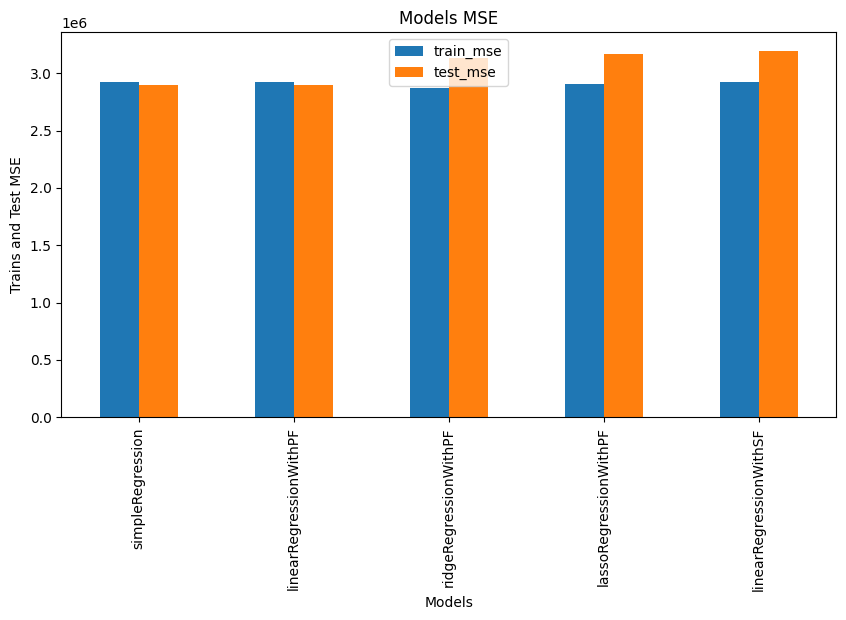

In [27]:
#Plotting the results obtained by executing different regression models.
df_results = pd.DataFrame(results)
df_results[['model','train_mse','test_mse']].sort_values('test_mse', ascending=True).plot(x='model', kind='bar',  figsize=(10,5))

plt.xlabel("Models")
plt.ylabel("Trains and Test MSE")
plt.title("Models MSE")
plt.show()

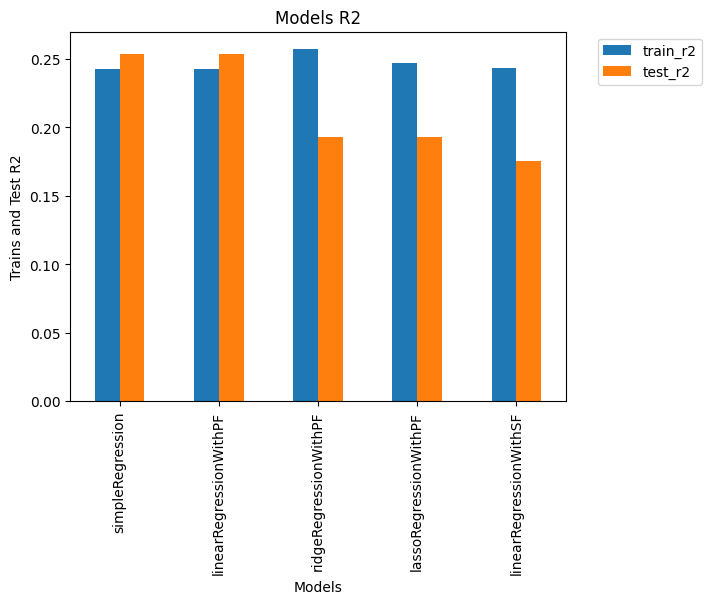

In [28]:
# Comparing final results for train r2 and test r2 by using visualization
df_results = pd.DataFrame(results)
df_results[['model', 'train_r2', 'test_r2']].sort_values('test_r2', ascending=False).plot(x='model', kind='bar',stacked=False)

plt.xlabel("Models")
plt.ylabel("Trains and Test R2")
plt.title("Models R2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [29]:
#Permutation Importance
#Evaluating what are the most important features
scoring= ['neg_mean_squared_error']

#Using the best model and the best estimator obtained
r_multi= permutation_importance(gscv_linreg.best_estimator_, X_test[X.columns], y_test, scoring=scoring, random_state=42)

In [30]:
importance_tr= dict(zip(X_train.columns, r_multi['neg_mean_squared_error']['importances_mean']))
importance_tr = {k: v for k, v in sorted(importance_tr.items(), key=lambda x:x[1],reverse=True)}
import_df= pd.DataFrame(importance_tr.values(), index= importance_tr.keys(), columns=['Importances'])
display(importance_tr)

{'year': np.float64(661706.8654650537),
 'model': np.float64(476378.70867808757),
 'condition': np.float64(424417.54663292284),
 'state': np.float64(111492.7386942571),
 'cylinders': np.float64(78592.07983460938),
 'odometer': np.float64(76256.42385205199),
 'title_status': np.float64(42146.47735563349),
 'type': np.float64(1002.2027193978429),
 'manufacturer': np.float64(12.39259058367461),
 'transmission': np.float64(-227.19034730307757),
 'fuel': np.float64(-255.27046795804054)}

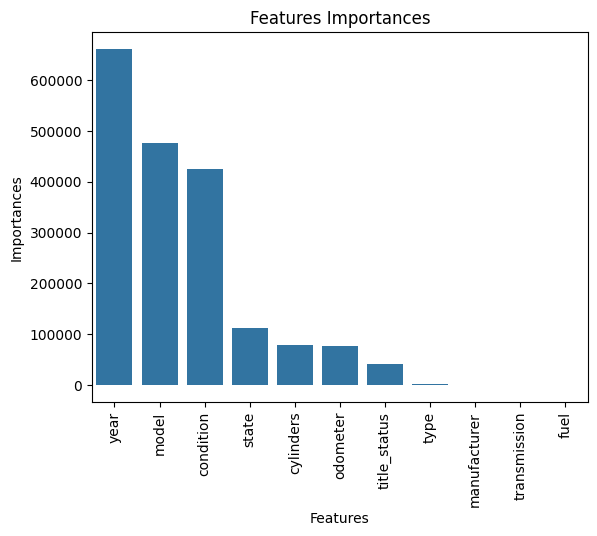

In [31]:
# Visualization of the importance of each feature vs the price
df_importances= import_df.reset_index()
sns.barplot(data=df_importances, x='index', y='Importances')

plt.xlabel("Features")
plt.ylabel("Importances")
plt.title("Features Importances")
plt.xticks(rotation=90)
plt.show()

[Text(0.5, 1.0, 'Correlation Heatmap')]

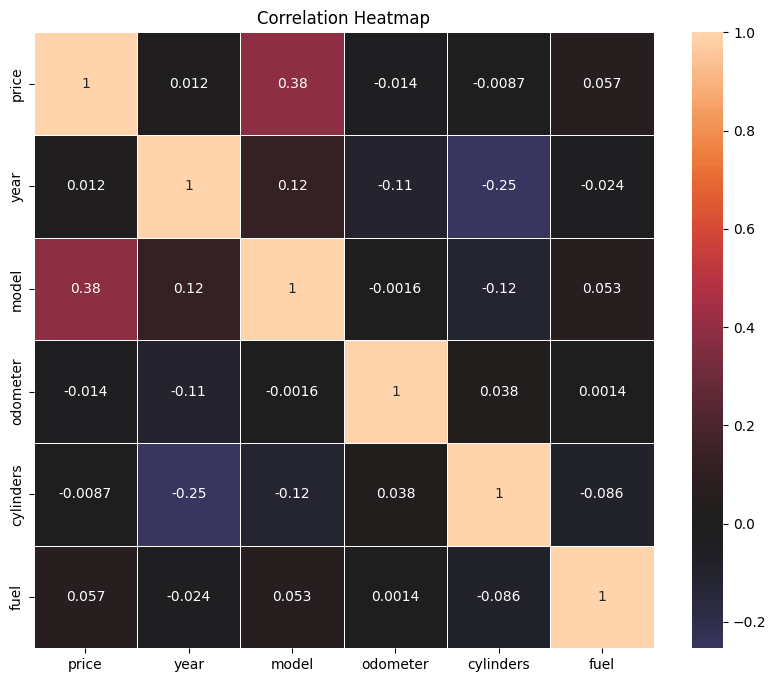

In [32]:
#Correlation using  the top 5 features
features_importances= ["price","year", "model", "odometer", "cylinders", "fuel"]
target_encoder= TargetEncoder()
df_target_encoded=target_encoder.fit_transform(df_without_outliers[features_importances], df_without_outliers["price"])

f,ax= plt.subplots(figsize=(10,8))
sns.heatmap(df_target_encoded.corr(), center=0,linewidth=.7,annot=True).set(title='Correlation Heatmap')



### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [33]:
df= df_without_outliers.copy()
df.sample(10)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,state
151495,5895,2006,ford,F150,excellent,6,gas,129055.0,clean,automatic,pickup,in
131208,2900,2007,chevrolet,Cobalt,good,4,gas,149296.0,clean,manual,other,id
41229,5700,2011,other,Scion Xb,excellent,4,gas,185000.0,clean,manual,hatchback,ca
200479,5995,2008,chevrolet,Uplander,good,6,gas,122603.0,clean,automatic,van,mi
37752,6999,2011,hyundai,Sonata Gls,good,6,gas,194416.0,clean,automatic,other,ca
292206,2350,2007,dodge,Grand Caravan,good,6,gas,170000.0,clean,automatic,other,oh
337720,5495,2010,pontiac,Vibe 1.8L,good,4,gas,126513.0,clean,automatic,hatchback,pa
261197,4995,2009,hyundai,Elantra Touring,good,6,gas,97000.0,clean,automatic,other,nm
87894,5550,1998,ford,E350 Passenger Van,good,6,gas,73000.0,clean,automatic,other,ct
165760,3500,2006,chevrolet,Equinox,good,6,gas,149743.0,clean,automatic,SUV,ks


In [34]:
#Categorizing the data to improve visualization. Using year and odometer
# year --> year_category: Using the descriptive categories below
#odometer  -->odometer_category: Classifying by using odometer ranges
#Vintage car: Manufactured between 1919 and 1930. Either a survivor or restore in conformance to the original manufacturer specifications
#Antique car: Manufactured 1975 or earlier (>45 years old). Either a survivor or restore in conformance to the original manufacturer specifications
#Classic car: Manufactured 2000 or earlier (>20 years old)
#Modern car: Manufactured 2000 or earlier (>10 years old)
#New Model: Manufactured 2017 or newest (5 years old)
min_year= min(df['year'])
max_year= max(df['year'])
year_bins = [min_year,max_year-45, max_year-20, max_year-10, max_year-5, max_year]
year_categories= ['Vintage', 'Antique', 'Classic', 'Modern', 'New Model']

df['year_category'] = pd.cut(df['year'], bins=year_bins, labels=year_categories, include_lowest =True)

#Odometer categories
max_odometer= max(df['odometer'])
odometer_bins= [0, 15000, 40000, 70000, max_odometer]
odometer_categories= ['New','Low', 'Medium', 'High']
df['odometer_category']= pd.cut(df['odometer'],odometer_bins,labels=odometer_categories, include_lowest=True)

display(df.sample(10))
display(year_bins)
display(odometer_bins)



,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,state,year_category,odometer_category
113630,4600,2005,bmw,X3 3.0I,good,6,gas,158386.0,clean,automatic,SUV,fl,Classic,High
250745,5500,2012,fiat,500,good,6,gas,90000.0,clean,automatic,other,nj,Classic,High
419762,2200,2008,buick,Lacrosse,fair,6,gas,159000.0,clean,automatic,sedan,wi,Classic,High
332293,500,2018,jeep,Grand Cherokee,good,6,gas,15000.0,clean,automatic,other,pa,New Model,New
334348,2995,1994,pontiac,Bonneville Sse,excellent,6,gas,160000.0,clean,automatic,other,pa,Antique,High
263771,5495,2011,hyundai,Elantra,excellent,4,gas,152000.0,clean,automatic,sedan,ny,Classic,High
190364,5500,2005,honda,Civic Ex,excellent,4,gas,130134.0,clean,automatic,sedan,ma,Classic,High
416485,6879,2010,hyundai,Sonata,good,6,gas,96011.0,clean,automatic,other,wi,Classic,High
233051,4995,2008,chevrolet,Impala,excellent,6,gas,123017.0,clean,automatic,sedan,nc,Classic,High
56906,3490,2008,kia,Rio,good,4,gas,116000.0,clean,manual,sedan,ca,Classic,High


[1948, 1977, 2002, 2012, 2017, 2022]

[0, 15000, 40000, 70000, 10000000.0]

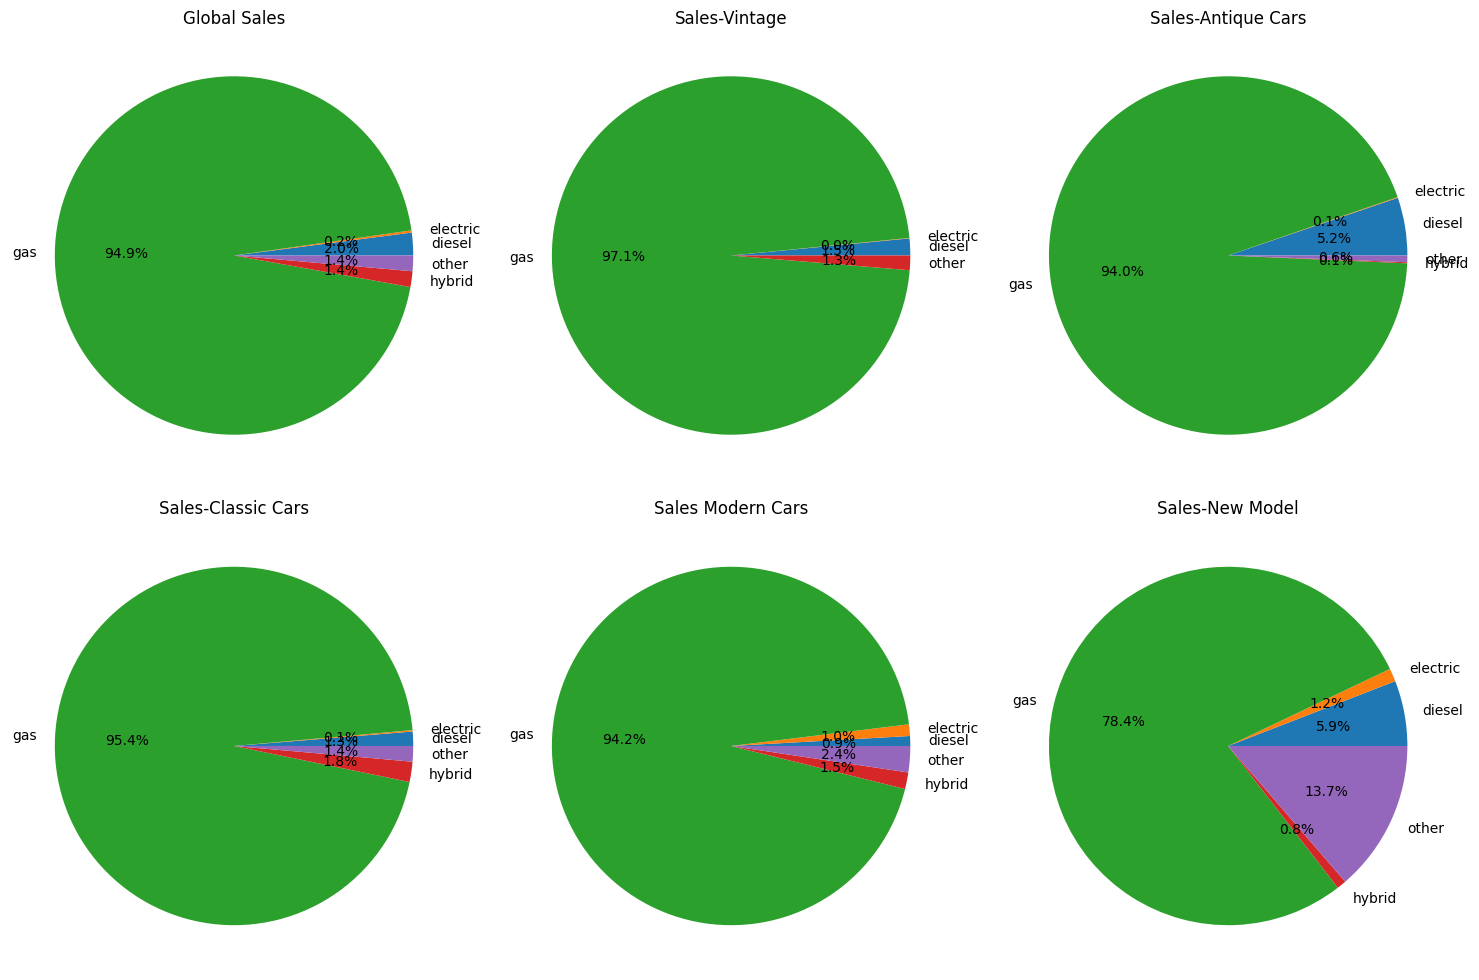

In [35]:
#Sales by Year Category vs Fuel
fig, ax =plt.subplots(2,3, figsize=(15,10))

#Original plot
df_sales_by_fuel= df.groupby('fuel')['price'].agg(sum).reset_index()
ax[0][0].set_title('Global Sales')
ax[0][0].pie(df_sales_by_fuel['price'], labels=df_sales_by_fuel['fuel'], autopct='%1.1f%%')

df_sales_by_q4= df.query('year_category=="Vintage"').groupby('fuel')['price'].agg(sum).reset_index()
ax[0][1].set_title('Sales-Vintage')
ax[0][1].pie(df_sales_by_q4['price'], labels=df_sales_by_q4['fuel'], autopct='%1.1f%%')

df_sales_by_q3= df.query('year_category=="Antique"').groupby('fuel')['price'].agg(sum).reset_index()
ax[0][2].set_title('Sales-Antique Cars')
ax[0][2].pie(df_sales_by_q3['price'], labels=df_sales_by_q3['fuel'], autopct='%1.1f%%')

df_sales_by_q2= df.query('year_category=="Classic"').groupby('fuel')['price'].agg(sum).reset_index()
ax[1][0].set_title('Sales-Classic Cars')
ax[1][0].pie(df_sales_by_q2['price'], labels=df_sales_by_q2['fuel'], autopct='%1.1f%%')

df_sales_by_q2= df.query('year_category=="Modern"').groupby('fuel')['price'].agg(sum).reset_index()
ax[1][1].set_title('Sales Modern Cars')
ax[1][1].pie(df_sales_by_q2['price'], labels= df_sales_by_q2['fuel'],autopct= '%1.1f%%')

df_sales_by_q2= df.query('year_category=="New Model"').groupby('fuel')['price'].agg(sum).reset_index()
ax[1][2].set_title('Sales-New Model')
ax[1][2].pie(df_sales_by_q2 ['price'], labels=df_sales_by_q2['fuel'], autopct='%1.1f%%')

plt.tight_layout()

In [36]:
#Total sales value by manufacture year
px.line(df[['year', 'price']].groupby('year').agg(sum)[['price']], title='Total Sales by Manufacture Year')

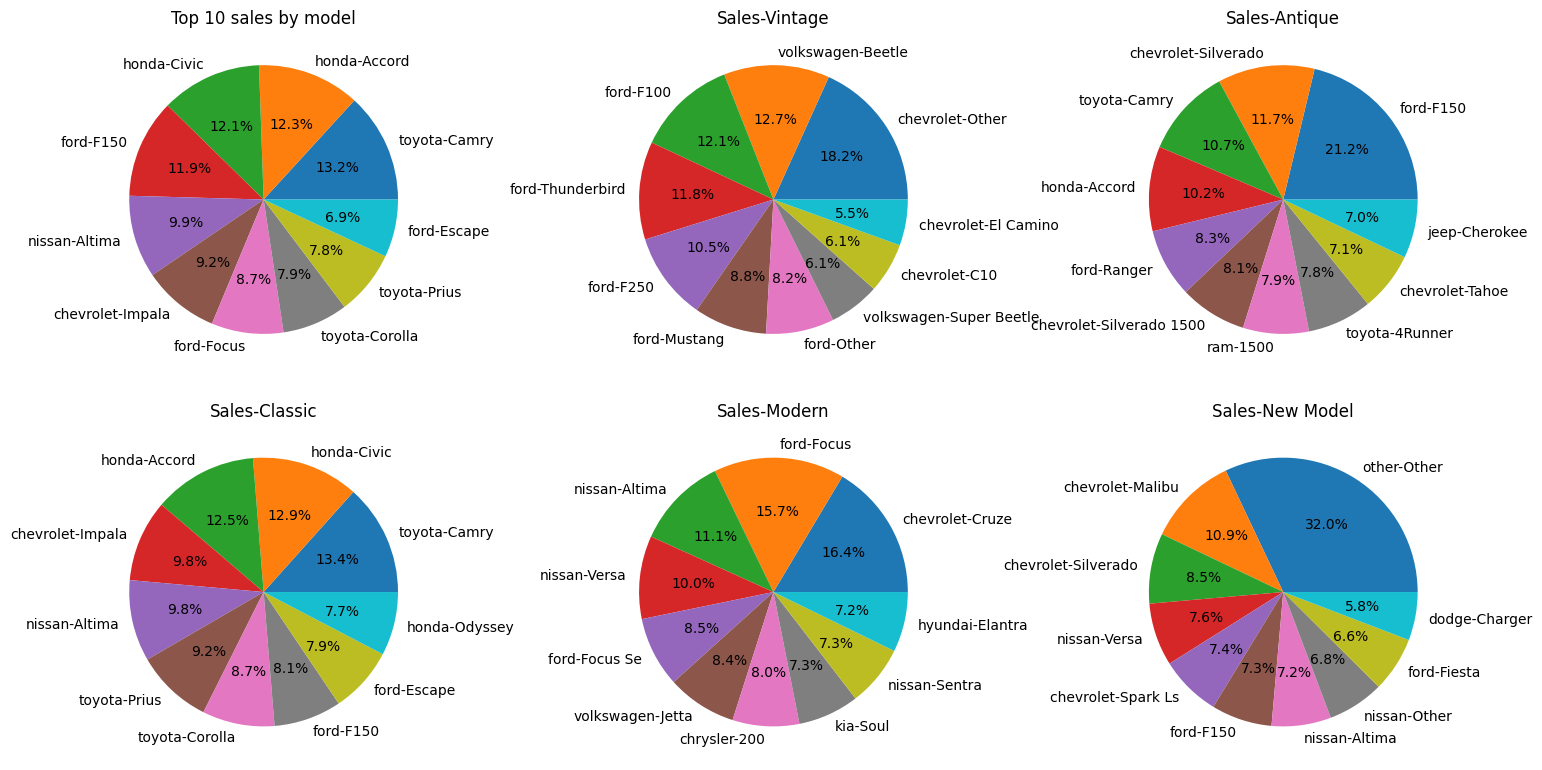

In [37]:
#Total sales by year category vs top 10 models
fig, ax = plt.subplots(2, 3, figsize=(15,8))

df_sales_by_model= df.groupby(['manufacturer', 'model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[0][0].set_title('Top 10 sales by model')
ax[0][0].pie(df_sales_by_model['price'], labels=df_sales_by_model['manufacturer'] + '-' + df_sales_by_model['model'], autopct='%1.1f%%')

df_sales_by_q4= df.query('year_category=="Vintage"').groupby(['manufacturer', 'model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[0][1].set_title('Sales-Vintage')
ax[0][1].pie(df_sales_by_q4['price'], labels= df_sales_by_q4['manufacturer'] + '-' + df_sales_by_q4['model'], autopct='%1.1f%%')

df_sales_by_q3= df.query('year_category=="Antique"').groupby(['manufacturer','model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[0][2].set_title('Sales-Antique')
ax[0][2].pie(df_sales_by_q3['price'], labels=df_sales_by_q3['manufacturer']+'-'+df_sales_by_q3['model'], autopct='%1.1f%%')

df_sales_by_q2_classic= df.query('year_category=="Classic"').groupby(['manufacturer', 'model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[1][0].set_title('Sales-Classic')
ax[1][0].pie(df_sales_by_q2_classic['price'], labels=df_sales_by_q2_classic['manufacturer']+'-'+df_sales_by_q2_classic['model'], autopct='%1.1f%%')

df_sales_by_q2_modern= df.query('year_category=="Modern"').groupby(['manufacturer','model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[1][1].set_title('Sales-Modern')
ax[1][1].pie(df_sales_by_q2_modern['price'], labels=df_sales_by_q2_modern['manufacturer']+'-'+df_sales_by_q2_modern['model'], autopct='%1.1f%%')

df_sales_by_q2_new_model= df.query('year_category=="New Model"').groupby(['manufacturer','model'])['price'].agg('sum').reset_index().sort_values('price', ascending=False).iloc[0:10]
ax[1][2].set_title('Sales-New Model')
ax[1][2].pie(df_sales_by_q2_new_model['price'], labels=df_sales_by_q2_new_model['manufacturer']+'-'+df_sales_by_q2_new_model['model'],autopct='%1.1f%%')

plt.tight_layout()

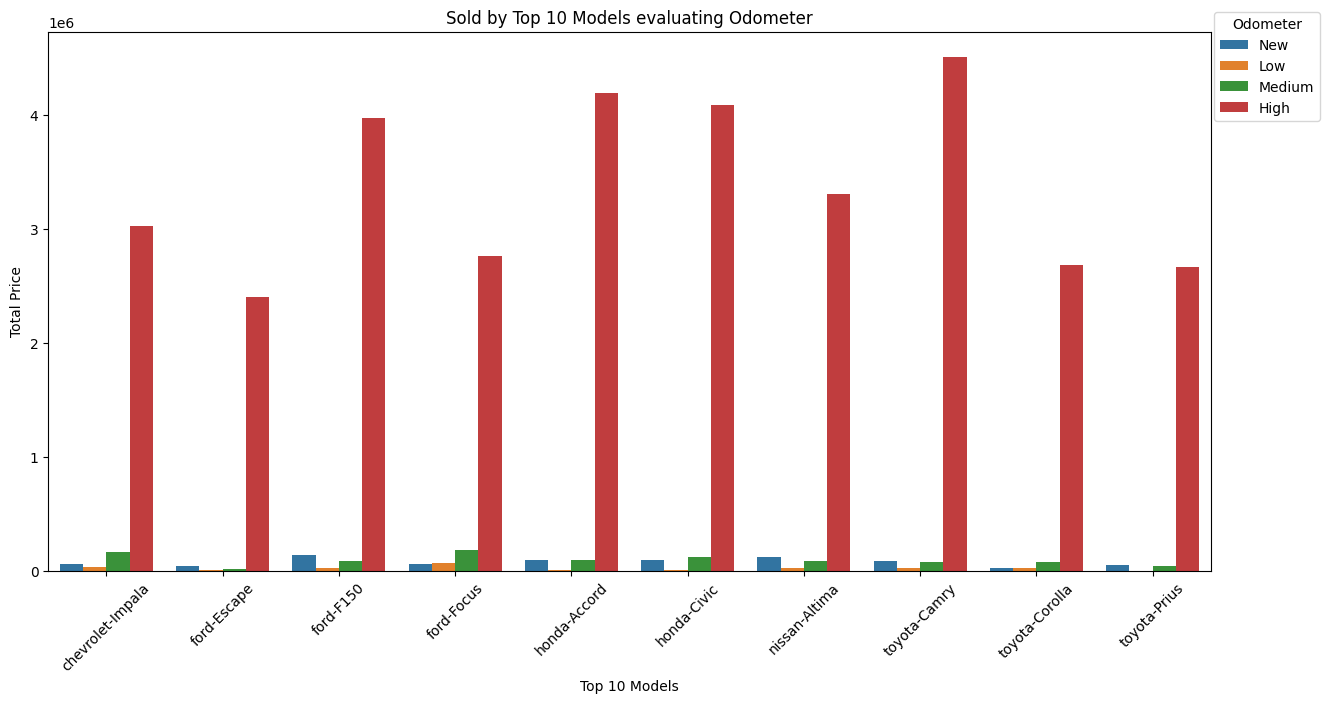

In [38]:
#Sold by Top 10 Models Evaluating Odometer

df_new=df.copy()
df_new['man_model']= df_new['manufacturer']+'-'+df_new['model']

df_topmodels= df_new.groupby(['manufacturer', 'model'])['price'].agg(sum).reset_index().sort_values('price', ascending=False).iloc[0:10]
df_topmodels['man_model']= df_topmodels['manufacturer']+'-'+df_topmodels['model']

top_models= df_topmodels['man_model'].unique()
df_data= df_new.query('man_model in @top_models'). groupby(['man_model', 'odometer_category'])['price'].agg(sum).reset_index()

plt.figure(figsize=(15,7))
sns.barplot(data=df_data, x='man_model', y='price', hue='odometer_category').set(title= 'Sold by Top 10 Models evaluating Odometer')
plt.xticks(rotation=45)
plt.xlabel('Top 10 Models')
plt.ylabel('Total Price')
plt.legend(bbox_to_anchor=(1.1,1.05), title="Odometer")
plt.show()

,man_model,odometer_category,price
0,chevrolet-Impala,New,0
1,chevrolet-Impala,Low,0
2,chevrolet-Impala,Medium,10000
3,chevrolet-Impala,High,0
4,chevrolet-Malibu,New,11990
5,chevrolet-Malibu,Low,5338
6,chevrolet-Malibu,Medium,4490
7,chevrolet-Malibu,High,281
8,dodge-Charger,New,0
9,dodge-Charger,Low,2541


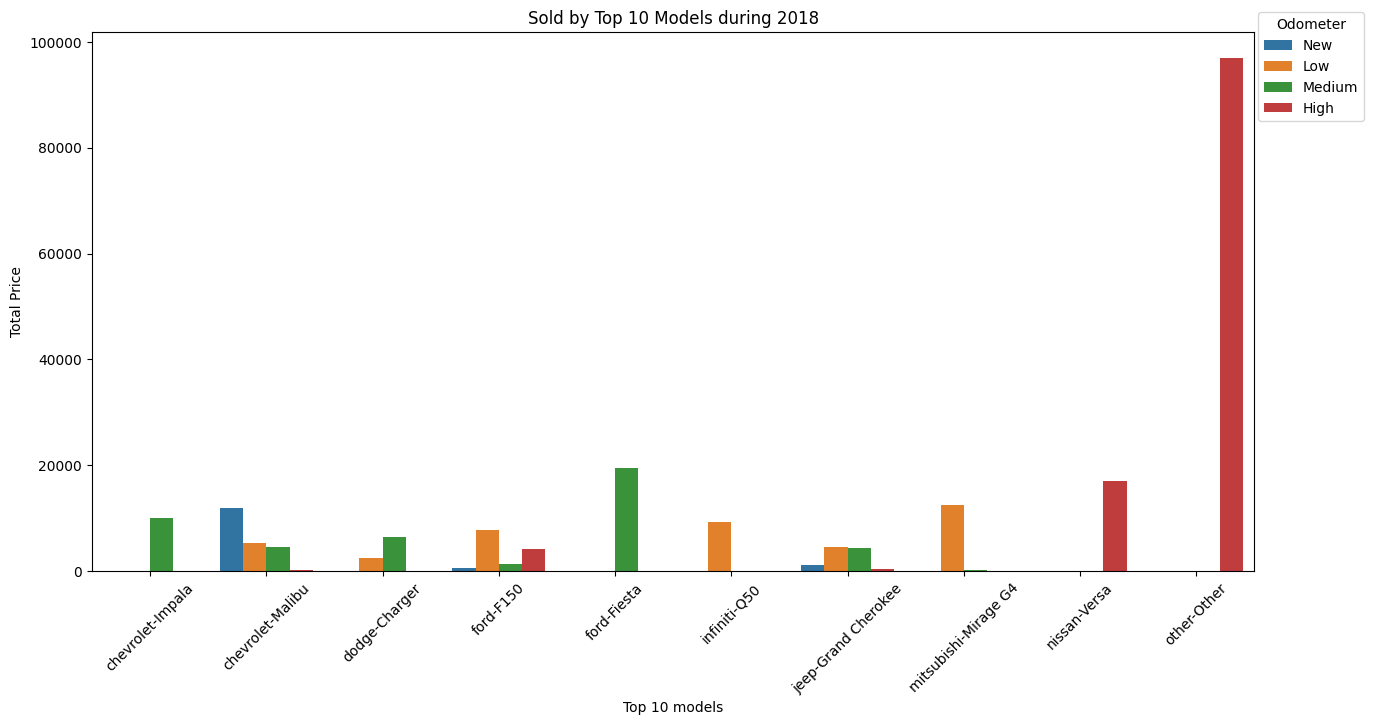

In [39]:
#Evaluating 2018(Year with most sales), the distribrution of top models and odometer.
df_new= df.copy()
df_new= df_new.query('year==2018')
df_new['man_model']= df_new['manufacturer']+'-'+df_new['model']

df_topmodels= df_new.groupby(['man_model']) ['price'].agg(sum).reset_index().sort_values('price', ascending=False).iloc[0:10]
top_models= df_topmodels['man_model'].unique()
df_data= df_new.query('man_model in(@top_models)').groupby(['man_model', 'odometer_category'])['price'].agg(sum).reset_index()

display(df_data)

plt.figure(figsize=(15,7))
sns.barplot(data=df_data, x='man_model', y='price', hue='odometer_category').set(title= 'Sold by Top 10 Models during 2018')
plt.xticks(rotation=45)
plt.xlabel('Top 10 models')
plt.ylabel('Total Price')
plt.legend(bbox_to_anchor=(1.1,1.05), title="Odometer")
plt.show()

([<matplotlib.patches.Wedge at 0x7a7b04cd61b0>,
 [Text(0.20892820315419167, 1.0799763913747193, 'other-Other'),
  Text(-1.0974681411731302, 0.07459007380338505, 'chevrolet-Malibu'),
  Text(-0.9525000759351574, -0.5502214148354456, 'ford-Fiesta'),
  Text(-0.5546719954450662, -0.9499152475189503, 'nissan-Versa'),
  Text(-0.09907708278467067, -1.0955289734493012, 'ford-F150'),
  Text(0.31026554208666546, -1.055336578250592, 'mitsubishi-Mirage G4'),
  Text(0.6340842603296933, -0.898853242082458, 'jeep-Grand Cherokee'),
  Text(0.8658296222930041, -0.6784829144200715, 'chevrolet-Impala'),
  Text(1.0174834307344303, -0.4180041485211527, 'infiniti-Q50'),
  Text(1.090919147088325, -0.14105110604345372, 'dodge-Charger')],
 [Text(0.11396083808410454, 0.5890780316589378, '43.9%'),
  Text(-0.5986189860944346, 0.040685494801846384, '10.0%'),
  Text(-0.5195454959646313, -0.3001207717284249, '8.8%'),
  Text(-0.30254836115185424, -0.518135589555791, '7.7%'),
  Text(-0.05404204515527491, -0.597561258245

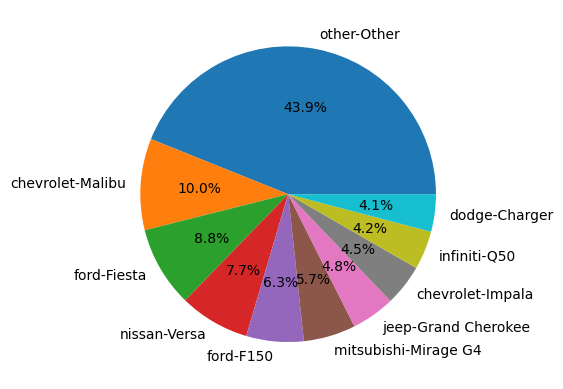

In [40]:
df_2018_top=df_data.groupby('man_model')['price'].sum().reset_index().sort_values('price', ascending=False).iloc[0:10]
plt.pie(df_2018_top['price'], labels=df_2018_top['man_model'], autopct='%1.1f%%')
